# Predicting Chronotype from Daily Habits

In [768]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


## Load Dataset

In [769]:
df = pd.read_csv('Raw_Data.csv')
df.head()

,Timestamp,1. What time do you usually wake up on weekdays?,2. What time do you usually go to bed on weekdays?,3. When do you feel most productive during the day?,4. How many cups of coffee do you drink per day?,5. Which of the following best describes your overall productivity pattern?
0,3/21/2026 14:17,6:00 AM - 8:00 AM,After 12:00 AM,Afternoon (12 PM - 6 PM),0,I am a morning person
1,3/21/2026 16:53,Before 6:00 AM,Before 10:00 PM,Morning (6 AM - 12 AM),1,I am a night person
2,3/21/2026 16:54,8:00 AM - 10:00 AM,10:00 PM - 12:00 AM,Evening (6 PM - 9 PM),2,I am both
3,3/21/2026 16:54,After 10:00 AM,10:00 PM - 12:00 AM,Night (9 PM - 12 PM),2,I am a night person
4,3/21/2026 17:01,After 10:00 AM,Before 10:00 PM,Evening (6 PM - 9 PM),1,I am a night person


In [770]:
# Drop the first column (timestamp)

df = df.drop(columns= [df.columns[0]])
df.head()

,1. What time do you usually wake up on weekdays?,2. What time do you usually go to bed on weekdays?,3. When do you feel most productive during the day?,4. How many cups of coffee do you drink per day?,5. Which of the following best describes your overall productivity pattern?
0,6:00 AM - 8:00 AM,After 12:00 AM,Afternoon (12 PM - 6 PM),0,I am a morning person
1,Before 6:00 AM,Before 10:00 PM,Morning (6 AM - 12 AM),1,I am a night person
2,8:00 AM - 10:00 AM,10:00 PM - 12:00 AM,Evening (6 PM - 9 PM),2,I am both
3,After 10:00 AM,10:00 PM - 12:00 AM,Night (9 PM - 12 PM),2,I am a night person
4,After 10:00 AM,Before 10:00 PM,Evening (6 PM - 9 PM),1,I am a night person


In [771]:
df.columns

Index(['1. What time do you usually wake up on  weekdays?',
       '2. What time do you usually go to bed on weekdays?',
       '3. When do you feel most productive during the day?',
       '4. How many cups of coffee do you drink per day?',
       '5. Which of the following best describes your overall productivity pattern?'],
      dtype='object')

In [772]:
df.columns = [
    'wake_up_time',           # Renamed column for "What time do you usually wake up on weekdays?"
    'bed_time',               # Renamed column for "What time do you usually go to bed on weekdays?"
    'productivity_time',      # Renamed column for "When do you feel most productive during the day?"
    'caffeine_consump',       # Renamed column for "How many cups of coffee do you drink per day?"
    'productivity_pattern'    # Renamed column for "Which of the following best describes your overall productivity pattern?"
]

# Display the cleaned DataFrame with new column names
df.head()

,wake_up_time,bed_time,productivity_time,caffeine_consump,productivity_pattern
0,6:00 AM - 8:00 AM,After 12:00 AM,Afternoon (12 PM - 6 PM),0,I am a morning person
1,Before 6:00 AM,Before 10:00 PM,Morning (6 AM - 12 AM),1,I am a night person
2,8:00 AM - 10:00 AM,10:00 PM - 12:00 AM,Evening (6 PM - 9 PM),2,I am both
3,After 10:00 AM,10:00 PM - 12:00 AM,Night (9 PM - 12 PM),2,I am a night person
4,After 10:00 AM,Before 10:00 PM,Evening (6 PM - 9 PM),1,I am a night person


In [773]:
# Check the data types of the columns
print(df.dtypes)


wake_up_time            object
bed_time                object
productivity_time       object
caffeine_consump         int64
productivity_pattern    object
dtype: object


In [774]:
df.nunique()

wake_up_time            4
bed_time                3
productivity_time       4
caffeine_consump        5
productivity_pattern    3
dtype: int64

In [775]:
print(df['productivity_pattern'].value_counts())

productivity_pattern
I am a night person      29
I am a morning person    17
I am both                 6
Name: count, dtype: int64


In [776]:
# drop 'I am both' category
df = df[df['productivity_pattern'] != 'I am both']

In [777]:
print(df['productivity_pattern'].value_counts())

productivity_pattern
I am a night person      29
I am a morning person    17
Name: count, dtype: int64


In [778]:
df.shape

(46, 5)

## Checking Outliers (IQR Method)

In [779]:
# Calculate the IQR to identify the bounds for outliers
Q1 = df['caffeine_consump'].quantile(0.25)
Q3 = df['caffeine_consump'].quantile(0.75)
IQR = Q3 - Q1

# Define the outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out the rows that are outliers for 'caffeine_consump'
outliers_data = df[(df['caffeine_consump'] < lower_bound) | (df['caffeine_consump'] > upper_bound)]

# Display the outliers (all rows where caffeine_consump is an outlier)
display(outliers_data)

,wake_up_time,bed_time,productivity_time,caffeine_consump,productivity_pattern
11,After 10:00 AM,10:00 PM - 12:00 AM,Night (9 PM - 12 PM),4,I am a night person


In [780]:
df.nunique()

wake_up_time            4
bed_time                3
productivity_time       4
caffeine_consump        5
productivity_pattern    2
dtype: int64

## Exploratory Data Analysis (EDA)

C:\Users\iziij\AppData\Local\Temp\ipykernel_9868\1076638273.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='wake_up_time', data=df, palette='viridis', ax=ax1, order=df['wake_up_time'].value_counts().index)
C:\Users\iziij\AppData\Local\Temp\ipykernel_9868\1076638273.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')  # Rotate x-axis labels
C:\Users\iziij\AppData\Local\Temp\ipykernel_9868\1076638273.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='bed_time', data=df, palette='magma', ax=ax2, order=df['bed_time'].value_cou

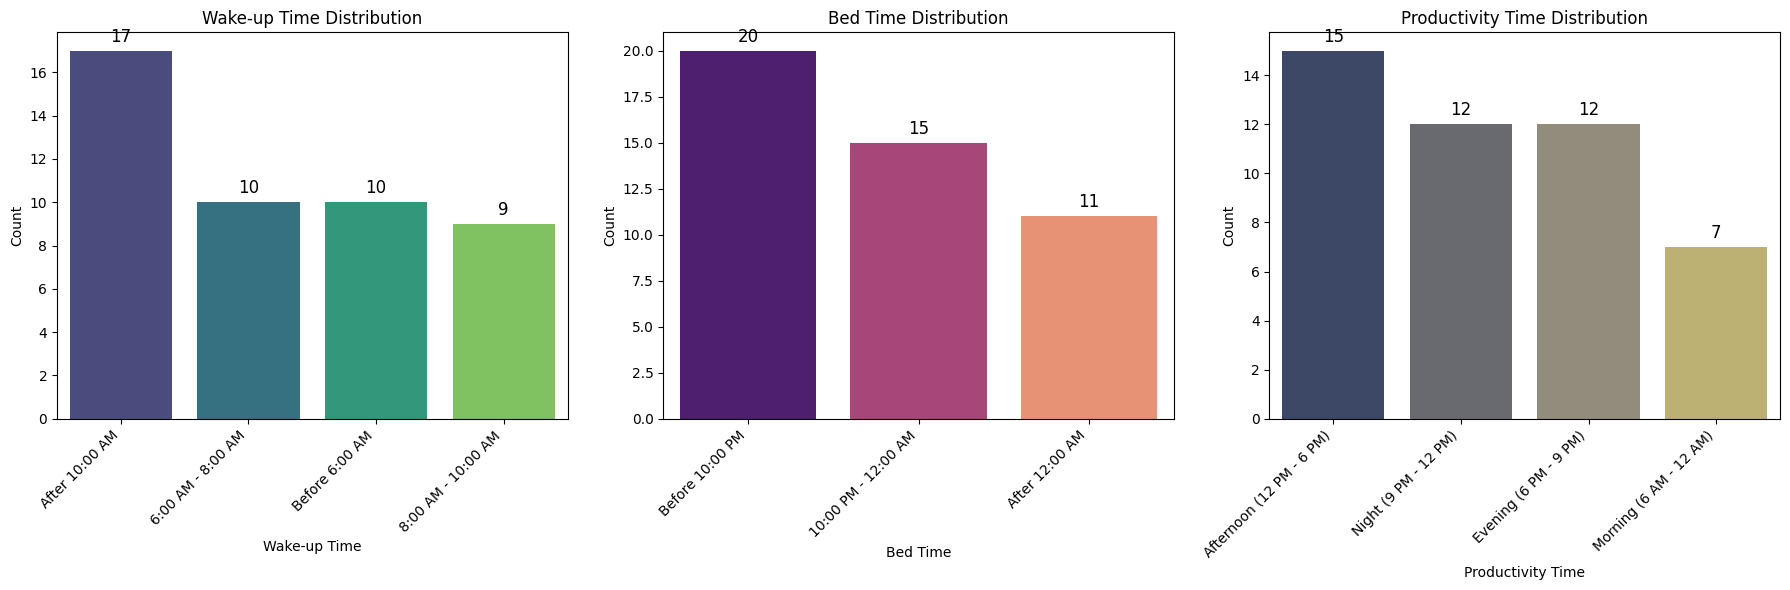

In [781]:


# Function to add count labels on each bar
def add_count_labels(ax):
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', fontsize=12, color='black', 
                    xytext=(0, 10), textcoords='offset points')


# Create a single row of 3 subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# Plotting distribution of 'wake_up_time' (Horizontal bars with count labels)
sns.countplot(x='wake_up_time', data=df, palette='viridis', ax=ax1, order=df['wake_up_time'].value_counts().index)
ax1.set(title='Wake-up Time Distribution', xlabel='Wake-up Time', ylabel='Count')
add_count_labels(ax1)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')  # Rotate x-axis labels

# Plotting distribution of 'bed_time' (Horizontal bars with count labels)
sns.countplot(x='bed_time', data=df, palette='magma', ax=ax2, order=df['bed_time'].value_counts().index)
ax2.set(title='Bed Time Distribution', xlabel='Bed Time', ylabel='Count')
add_count_labels(ax2)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')  # Rotate x-axis labels

# Plotting distribution of 'productivity_time' (Horizontal bars with count labels)
sns.countplot(x='productivity_time', data=df, palette='cividis', ax=ax3, order=df['productivity_time'].value_counts().index)
ax3.set(title='Productivity Time Distribution', xlabel='Productivity Time', ylabel='Count')
add_count_labels(ax3)
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha='right')  # Rotate x-axis labels

# Adjust the layout and spacing to fit the graphs neatly
plt.tight_layout()
plt.show()

C:\Users\iziij\AppData\Local\Temp\ipykernel_9868\3933287041.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='productivity_pattern', data=df, palette='coolwarm', ax=ax1)


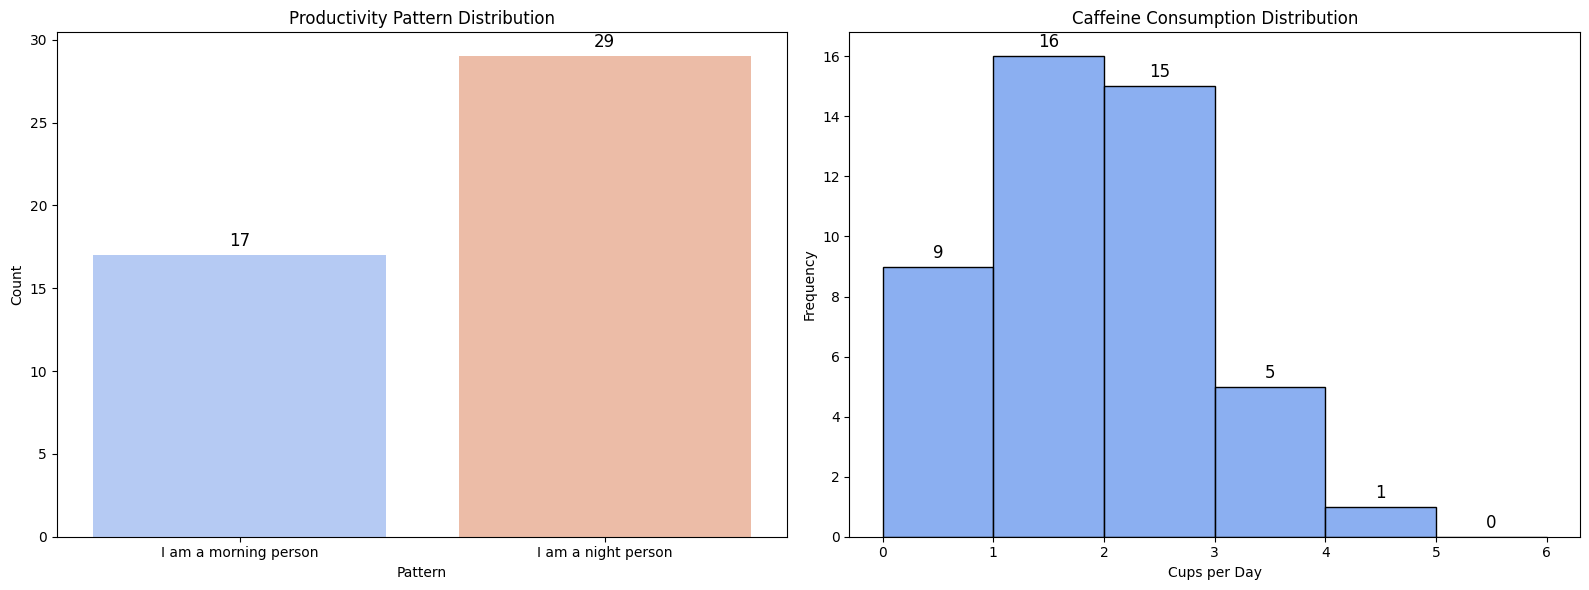

In [782]:
# Create subplots in a single row with 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plotting distribution of 'productivity_pattern' (Categorical - countplot)
sns.countplot(x='productivity_pattern', data=df, palette='coolwarm', ax=ax1)
ax1.set(title='Productivity Pattern Distribution', xlabel='Pattern', ylabel='Count')

# Add count labels to each bar
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}', 
                 (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha='center', va='center', fontsize=12, color='black', 
                 xytext=(0, 10), textcoords='offset points')


# Plotting distribution of 'caffeine_consump'

ax = sns.histplot(df['caffeine_consump'], bins=np.arange(0, 7, 1), kde=False, color='cornflowerblue')
plt.title('Caffeine Consumption Distribution')
plt.xlabel('Cups per Day')
plt.ylabel('Frequency')

# Add count labels to each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=12, color='black', 
                xytext=(0, 10), textcoords='offset points')

# Adjust layout
plt.tight_layout()
plt.show()

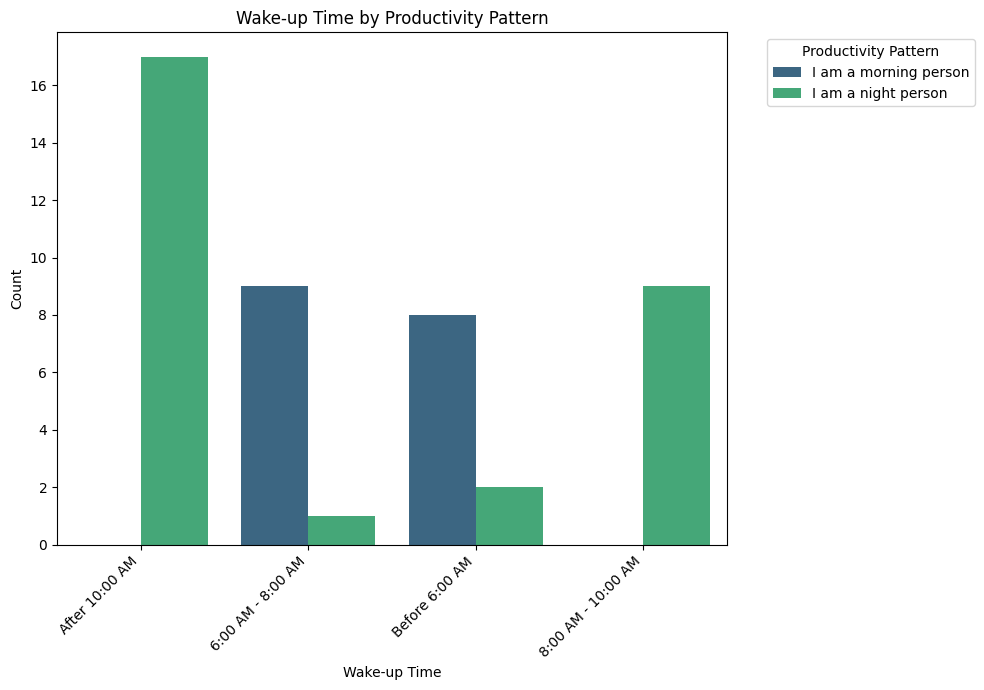

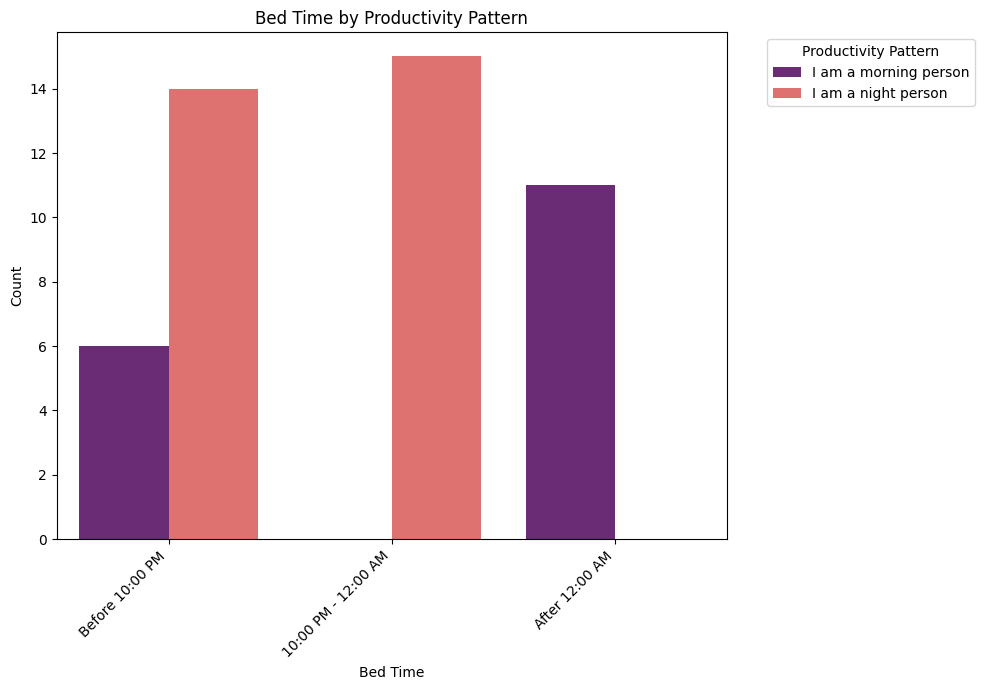

In [783]:

# Plotting relationship between 'wake_up_time' and 'productivity_pattern'
plt.figure(figsize=(10, 7))
sns.countplot(x='wake_up_time', hue='productivity_pattern', data=df, palette='viridis', order=df['wake_up_time'].value_counts().index)
plt.title('Wake-up Time by Productivity Pattern')
plt.xlabel('Wake-up Time')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Productivity Pattern', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Plotting relationship between 'bed_time' and 'productivity_pattern'
plt.figure(figsize=(10, 7))
sns.countplot(x='bed_time', hue='productivity_pattern', data=df, palette='magma', order=df['bed_time'].value_counts().index)
plt.title('Bed Time by Productivity Pattern')
plt.xlabel('Bed Time')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Productivity Pattern', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## Mapping Categorical Features to numerical values

In [785]:

# Manual mapping of categorical features to numerical values
wake_map = {
    'Before 6:00 AM': 0,
    '6:00 AM - 8:00 AM': 1,
    '8:00 AM - 10:00 AM': 2,
    'After 10:00 AM': 3
}

bed_map = {
    'Before 10:00 PM': 0,
    '10:00 PM - 12:00 AM': 1,
    'After 12:00 AM': 2
}

prod_map = {
    'Morning (6 AM - 12 AM)': 0,
    'Afternoon (12 PM - 6 PM)': 1,
    'Evening (6 PM - 9 PM)': 2,
    'Night (9 PM - 12 PM)': 3
}

prod_pattern_map = {
    'I am a morning person': 0,
    'I am a night person': 1
}

# Apply the mapping to the columns
df['wake_up_time'] = df['wake_up_time'].map(wake_map)
df['bed_time'] = df['bed_time'].map(bed_map)
df['productivity_time'] = df['productivity_time'].map(prod_map)
df['productivity_pattern'] = df['productivity_pattern'].map(prod_pattern_map)

# Check the result
df.head()

,wake_up_time,bed_time,productivity_time,caffeine_consump,productivity_pattern
0,1,2,1,0,0
1,0,0,0,1,1
3,3,1,3,2,1
4,3,0,2,1,1
6,2,1,2,1,1


## Correlation Matrix

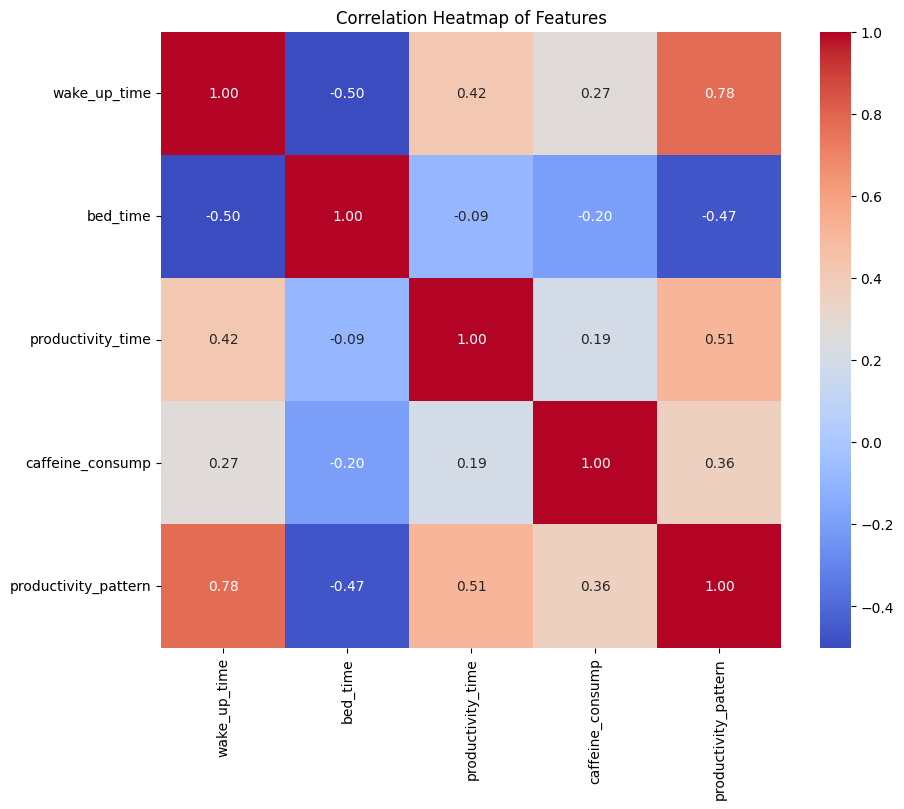

In [786]:

# Calculate the correlation matrix for the encoded DataFrame
correlation_matrix = df.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Features')
plt.show()

## Train/Test Split From Scratch

In [787]:
# split data

data = df.to_numpy()

# Features (X) and target (y)
X = data[:, :4]  # Features (all columns except the last one)
y = data[:, 4]   # Target variable (the last column)

# Manually split data into 80% training and 20% testing
train_size = int(0.8 * len(X))  # 80% for training

# Train data (first 80%)
X_train = X[:train_size]
y_train = y[:train_size]

# Test data (remaining 20%)
X_test = X[train_size:]
y_test = y[train_size:]

# Print the shapes to verify the split
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

X_train shape: (36, 4)
X_test shape: (10, 4)
y_train shape: (36,)
y_test shape: (10,)


In [788]:
y_train = y_train.reshape(-1, 1)  # Reshape y to be a column vector
print(y_train.shape)

(36, 1)


In [789]:
y_test = y_test.reshape(-1, 1)  # Reshape y to be a column vector
print(y_test.shape)

(10, 1)


## Feature Scaling

In [790]:
# Feature scaling (standardization)
mean_X_train = np.mean(X_train, axis=0)
std_X_train = np.std(X_train, axis=0)

X_train_scaled = (X_train - mean_X_train) / std_X_train
X_test_scaled = (X_test - mean_X_train) / std_X_train
print(X_train_scaled[:5])  # Print the first 5 rows of the scaled training features

[[-0.59735098  1.4596009  -0.73015274 -1.46726488]
 [-1.39381895 -1.04257207 -1.74113346 -0.45146612]
 [ 0.99558497  0.20851441  1.2918087   0.56433265]
 [ 0.99558497 -1.04257207  0.28082798 -0.45146612]
 [ 0.19911699  0.20851441  0.28082798 -0.45146612]]


## Add Bias Term

In [791]:
# compute 1 to X_train
X_train_new = np.concatenate((np.ones((X_train_scaled.shape[0], 1)), X_train_scaled), axis=1)
X_test_new = np.concatenate((np.ones((X_test_scaled.shape[0], 1)), X_test_scaled), axis=1)
print(X_train_new[:5])  # Print the first 5 rows of the new training features with bias term
print("\n")
print(X_test_new[:5])   # Print the first 5 rows of the new test features with bias term

[[ 1.         -0.59735098  1.4596009  -0.73015274 -1.46726488]
 [ 1.         -1.39381895 -1.04257207 -1.74113346 -0.45146612]
 [ 1.          0.99558497  0.20851441  1.2918087   0.56433265]
 [ 1.          0.99558497 -1.04257207  0.28082798 -0.45146612]
 [ 1.          0.19911699  0.20851441  0.28082798 -0.45146612]]


[[ 1.         -0.59735098 -1.04257207 -1.74113346 -1.46726488]
 [ 1.          0.19911699  0.20851441  1.2918087  -0.45146612]
 [ 1.         -0.59735098 -1.04257207 -1.74113346 -0.45146612]
 [ 1.         -0.59735098 -1.04257207 -0.73015274 -0.45146612]
 [ 1.         -0.59735098  1.4596009  -0.73015274 -0.45146612]]


In [792]:
print(np.unique(y))

[0 1]


## Logistic Regression Function

In [793]:

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def hypothesis (X, theta):
    return sigmoid(np.dot(X, theta))

def compute_cost (X, y, theta):
    m = len(y)
    h = hypothesis (X, theta)
    epsilon = 1e-10  # avoid log(0)
    # Binary Cross-Entropy Loss
    cost = (-1 / m) * np.sum(y * np.log(h + epsilon) + (1 - y) * np.log(1 - h + epsilon))
    return cost

def gradient (X, y, theta):
    m = len(y)
    h = hypothesis (X, theta)
    grad = (1 / m) * np.dot(X.T, (h - y))
    return grad

def predict_binary(X, theta, threshold=0.5):
    h = hypothesis (X, theta)
    return (h >= threshold).astype(int)

## Model Training (From Scratch)

In [794]:

# Initialize weights (theta) as a vector for binary classification
theta = np.zeros((X_train_new.shape[1], 1))

lr = 0.1
num_iterations = 500

cost_history = [] # To store cost at each iteration

for i in range(1, num_iterations + 1):
    grad = gradient (X_train_new, y_train, theta)
    theta -= lr * grad
    cost = compute_cost (X_train_new, y_train, theta)
    cost_history.append(cost)

    print(f'Iteration {i}, Cost: {cost:.4f}')

print('\nTraining Complete.')

Iteration 1, Cost: 0.6631
Iteration 2, Cost: 0.6357
Iteration 3, Cost: 0.6108
Iteration 4, Cost: 0.5880
Iteration 5, Cost: 0.5672
Iteration 6, Cost: 0.5482
Iteration 7, Cost: 0.5308
Iteration 8, Cost: 0.5148
Iteration 9, Cost: 0.5001
Iteration 10, Cost: 0.4865
Iteration 11, Cost: 0.4740
Iteration 12, Cost: 0.4624
Iteration 13, Cost: 0.4516
Iteration 14, Cost: 0.4416
Iteration 15, Cost: 0.4323
Iteration 16, Cost: 0.4237
Iteration 17, Cost: 0.4156
Iteration 18, Cost: 0.4080
Iteration 19, Cost: 0.4009
Iteration 20, Cost: 0.3942
Iteration 21, Cost: 0.3879
Iteration 22, Cost: 0.3820
Iteration 23, Cost: 0.3764
Iteration 24, Cost: 0.3711
Iteration 25, Cost: 0.3662
Iteration 26, Cost: 0.3614
Iteration 27, Cost: 0.3570
Iteration 28, Cost: 0.3527
Iteration 29, Cost: 0.3487
Iteration 30, Cost: 0.3448
Iteration 31, Cost: 0.3412
Iteration 32, Cost: 0.3377
Iteration 33, Cost: 0.3344
Iteration 34, Cost: 0.3312
Iteration 35, Cost: 0.3281
Iteration 36, Cost: 0.3252
Iteration 37, Cost: 0.3224
Iteration 

## Learned Parameters

In [795]:
print('Learned Parameters:', theta.flatten())


Learned Parameters: [ 1.43874223  2.03228429 -0.83630747  0.38429511  0.50577078]


## Probabilities During Train and Test

In [805]:

train_probs = sigmoid(np.matmul(X_train_new, theta))
test_probs = sigmoid(np.matmul(X_test_new, theta))

train_pred = (train_probs >= 0.5).astype(int)
test_pred = (test_probs >= 0.5).astype(int)



print("Average Train Probability for Class 1:")
print(f"{np.mean(train_probs):.2f}")

print("Average Test Probability for Class 1:")
print(f"{np.mean(test_probs):.2f}")


Average Train Probability for Class 1:
0.66
Average Test Probability for Class 1:
0.63


## Cost over Iterations Graph

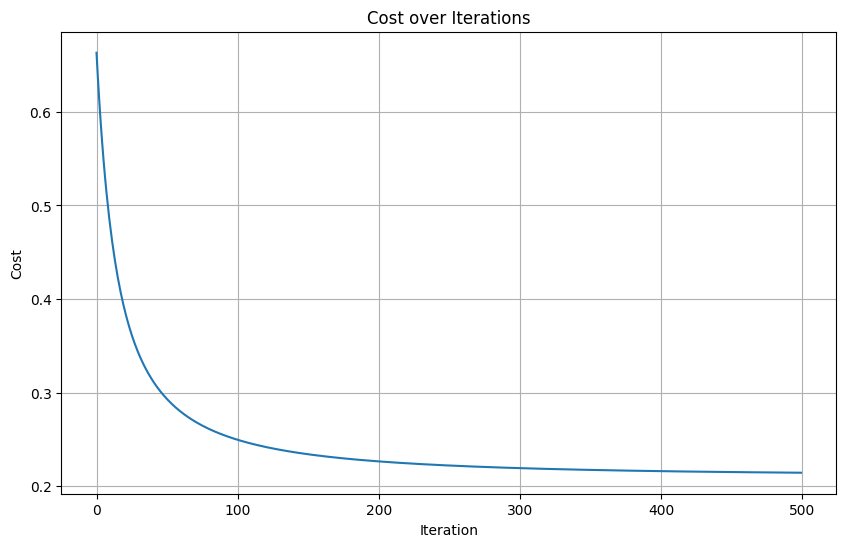

In [797]:
plt.figure(figsize=(10, 6))
plt.plot(cost_history)
plt.title('Cost over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.grid(True)
plt.show()

## Model Accuracy (from scratch)



In [798]:

X_test_new = np.concatenate((np.ones((X_test_scaled.shape[0], 1)), X_test_scaled), axis=1)

# Use the binary prediction function
y_pred_train = predict_binary(X_train_new, theta)
y_pred_test = predict_binary(X_test_new, theta)

# y_train and y_test are already labels (0 or 1), no need for one-hot conversion here

train_acc = np.mean(y_pred_train == y_train) * 100
test_acc = np.mean(y_pred_test == y_test) * 100

print(f'Final Training Accuracy: {train_acc:.2f}%')
print(f'Final Test Accuracy: {test_acc:.2f}%')

Final Training Accuracy: 88.89%
Final Test Accuracy: 80.00%


## Confusion Matrix

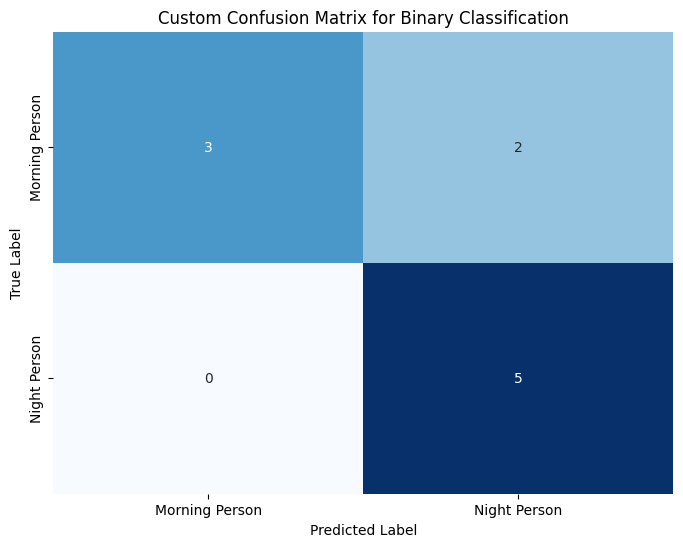

In [799]:

def custom_confusion_matrix(y_true, y_pred, labels=[0, 1]):
    # Initialize matrix with zeros
    cm = np.zeros((len(labels), len(labels)), dtype=int)

    for i in range(len(y_true)):
        true_label = y_true[i, 0] if y_true.ndim > 1 else y_true[i]
        predicted_label = y_pred[i, 0] if y_pred.ndim > 1 else y_pred[i]

        # Find indices for true and predicted labels
        true_idx = labels.index(true_label)
        pred_idx = labels.index(predicted_label)

        cm[true_idx, pred_idx] += 1
    return cm

# Compute confusion matrix for the test set
cm_custom = custom_confusion_matrix(y_test, y_pred_test, labels=[0, 1])

# Plot the custom confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Morning Person', 'Night Person'], yticklabels=['Morning Person', 'Night Person'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Custom Confusion Matrix for Binary Classification')
plt.show()

##  Implement Classification Report (Precision, Recall, F1-Score)

In [800]:
# Helper function to calculate precision, recall, and f1-score for a single class
def calculate_prf(y_true, y_pred, class_label):
    true_positives = np.sum((y_true == class_label) & (y_pred == class_label))
    false_positives = np.sum((y_true != class_label) & (y_pred == class_label))
    false_negatives = np.sum((y_true == class_label) & (y_pred != class_label))

    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return precision, recall, f1_score

# Calculate metrics for each class
class_names = ['Morning Person', 'Night Person']

print("Custom Classification Report for Test Set:")
print(f"{'':<15}{'Precision':>10}{'Recall':>10}{'F1-Score':>10}")
print("-" * 50)

results = {}
for i, label_name in enumerate(class_names):
    y_true_flat = y_test.flatten() if y_test.ndim > 1 else y_test
    y_pred_flat = y_pred_test.flatten() if y_pred_test.ndim > 1 else y_pred_test

    precision, recall, f1_score = calculate_prf(y_true_flat, y_pred_flat, i)
    results[label_name] = {'precision': precision, 'recall': recall, 'f1-score': f1_score}
    print(f"{label_name:<15}{precision:>10.2f}{recall:>10.2f}{f1_score:>10.2f}")


Custom Classification Report for Test Set:
                Precision    Recall  F1-Score
--------------------------------------------------
Morning Person       1.00      0.60      0.75
Night Person         0.71      1.00      0.83


## Predicting on New data

In [ ]:
# Example: [6:00 AM - 8:00 AM, After 12:00 AM, Morning (6 AM - 12 PM), 2 cups of coffee]
person = np.array([[1, 2, 0, 2]], dtype=float) 

person_scal = (person - mean_X_train) / std_X_train
person_new = np.concatenate((np.ones((1, 1)), person_scal), axis=1)
person_prob = sigmoid(np.matmul(person_new, theta))
person_pred = (person_prob >= 0.5).astype(int)

print("Predicted probability:", float(person_prob.item()))
print("Predicted class:", int(person_pred.item()))

# Display the result
if int(person_pred.item()) == 1:
    print("Prediction: Night Person 🌙")
else:
    print("Prediction: Morning Person 🌞")



Predicted probability: 0.20107228057833756
Predicted class: 0
Prediction: Morning Person 🌞


In [802]:
import pickle

# Save model parameters
model_data = {
    'theta': theta,
    'x_mean': mean_X_train,
    'x_std': std_X_train
}

# Save to the current working directory
save_path = 'model.pkl'  # This will save the model in the same directory as the script or notebook

# Save model parameters to the specified file path
with open(save_path, 'wb') as f:
    pickle.dump(model_data, f)

print(f"✅ Model saved successfully to: {save_path}")
print(f"Model parameters saved:")


✅ Model saved successfully to: model.pkl
Model parameters saved:
